## Nonlinear Function

In [1]:
%matplotlib inline
import torch
import matplotlib.pyplot as plt

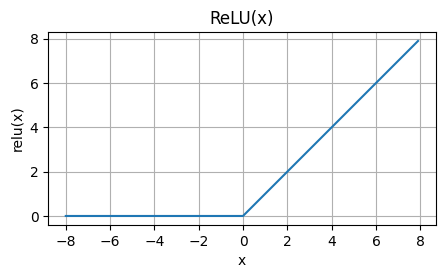

In [2]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad= True)
y = torch.relu(x)

plt.figure(figsize=(5, 2.5))
plt.plot(x.detach(), y.detach())
plt.title('ReLU(x)')
plt.xlabel('x')
plt.ylabel('relu(x)')
plt.grid(True)
plt.show()

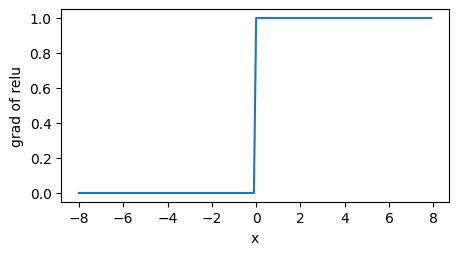

In [3]:
y.backward(torch.ones_like(x), retain_graph=True)
plt.figure(figsize=(5, 2.5))
plt.xlabel('x')
plt.ylabel('grad of relu')
plt.plot(x.detach(), x.grad)
plt.show()

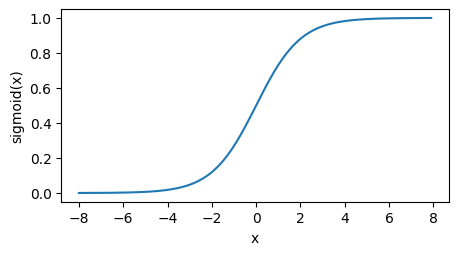

In [4]:
y = torch.sigmoid(x)
plt.figure(figsize=(5, 2.5))
plt.plot(x.detach(), y.detach())
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.show()

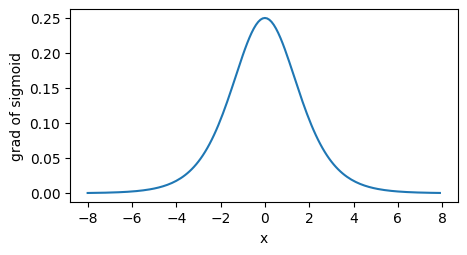

In [5]:
x.grad.data.zero_()
y.backward(torch.ones_like(x), retain_graph=True)
plt.figure(figsize=(5, 2.5))
plt.plot(x.detach(), x.grad)
plt.xlabel('x')
plt.ylabel('grad of sigmoid')
plt.show()

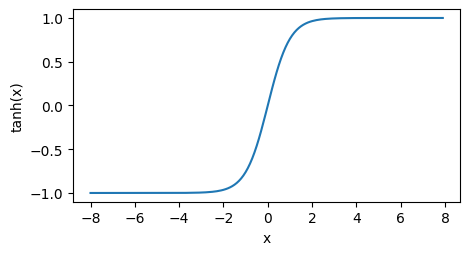

In [6]:
y = torch.tanh(x)
plt.figure(figsize=(5, 2.5))
plt.plot(x.detach(), y.detach())
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.show()

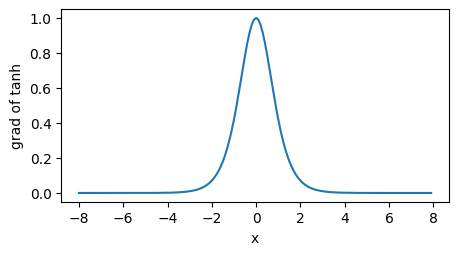

In [7]:
x.grad.data.zero_()
y.backward(torch.ones_like(x), retain_graph=True)
plt.figure(figsize=(5, 2.5))
plt.plot(x.detach(), x.grad)
plt.xlabel('x')
plt.ylabel('grad of tanh')
plt.show()

## MLP

In [14]:
import torch
from torch import nn
from torchvision import transforms
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib_inline import backend_inline
import torchvision
from torch.utils import data
from torchvision import transforms
import numpy

backend_inline.set_matplotlib_formats('svg')

In [17]:
def get_dataloader_workers():
    return 4

def load_data_fashion_mnist(batch_size, resize = None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root = "../data", train = True, transform = trans, download = True
    )   
    mnist_test = torchvision.datasets.FashionMNIST(
        root = "../data", train = False, transform = trans, download = True
    )
    return(data.DataLoader(mnist_train, batch_size, shuffle = True, num_workers = get_dataloader_workers(), pin_memory=True),
           data.DataLoader(mnist_test, batch_size, shuffle = False, num_workers = get_dataloader_workers(), pin_memory=True))

In [18]:
batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size)

In [20]:
num_inputs, num_outputs, num_hiddens = 784, 10, 256

W1 = nn.Parameter(torch.randn(
    num_inputs, num_hiddens, requires_grad=True) * 0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))
W2 = nn.Parameter(torch.randn(
    num_hiddens, num_outputs, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

params = [W1, b1, W2, b2]

In [21]:
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

In [22]:
def net(X):
    X = X.reshape(-1, num_inputs)
    H = relu(X @ W1 + b1)
    return (H @ W2 + b2)

In [24]:
import matplotlib.pyplot as plt
from matplotlib_inline import backend_inline
from IPython import display

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    if xlim:
        axes.set_xlim(xlim)
    if ylim:
        axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid(True)

class Animator:  #@save
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        if legend is None:
            legend = []
        backend_inline.set_matplotlib_formats('svg')
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        self.config_axes = lambda: set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

class Accumulator:
    def __init__(self, n):
        self.data = [0, 0] * n
    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]
    def reset(self):
        self.data = [0, 0] * len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]
    
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis = 1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy(net, data_iter):
    if isinstance(net, torch.nn.Module):
        net.eval()
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

def train_epoch_ch3(net, train_iter, loss, updater):
    if isinstance(net, torch.nn.Module):
        net.train()
    metric = Accumulator(3)
    for X, y in train_iter:
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    return metric[0] / metric[2], metric[1] / metric[2]



def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    animator = Animator(xlabel = 'epoch', xlim = [1, num_epochs], ylim = [0.3, 0.9], 
                        legend = ['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

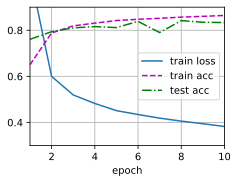

In [25]:
loss = nn.CrossEntropyLoss(reduction='none')

num_epochs, lr = 10, 0.1
updater = torch.optim.SGD(params, lr=lr)
train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)

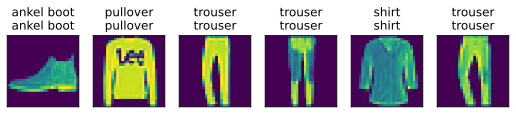

In [26]:
def get_fashion_mnist_labels(labels):
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'ankel boot']
    return [text_labels[int(i)] for i in labels]

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            ax.imshow(img.numpy())
        else:
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes


def predict_ch3(net, test_iter, n= 6):
    for X, y in test_iter:
        break
    trues = get_fashion_mnist_labels(y)
    preds = get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true + '\n' + pred for true, pred in zip(trues, preds)]
    show_images(X[0:n].reshape((n, 28, 28)), 1, n, titles = titles[0:n])

predict_ch3(net, test_iter)

## Brief Implemention

In [27]:
import torch
from torch import nn

In [28]:
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 256),
                    nn.ReLU(),
                    nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=10, bias=True)
)

In [30]:
batch_size = 256
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)

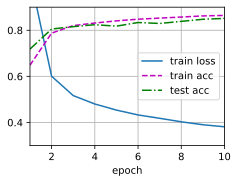

In [31]:
train_iter, test_iter = load_data_fashion_mnist(batch_size)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)